# Random Forest


O objetivo do projeto é prever a pontuação dos vinhos usando o algoritmo de Regressão de Random Forest para classificação multiclasse a partir de uma base de dados de avaliações de vinhos.
A base contém algumas características químicas do vinho que influemciam na sua qualidade.

**Caracaterísticas químicas do vinho:**
- Características dos Vinhos (Features)
- Fixed Acidity: Acidez fixa do vinho.
- Volatile Acidity: Acidez volátil do vinho.
- Citric Acid: Quantidade de ácido cítrico no vinho.
- Residual Sugar: Açúcar residual presente no vinho.
- Chlorides: Nível de cloretos no vinho.
- Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.
- Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.
- Density: Densidade do vinho.
- pH: Nível de pH do vinho.
- Sulphates: Quantidade de sulfatos no vinho.
- Alcohol: Teor alcoólico do vinho.

**Qualidade do Vinho (Variável de Saída,Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots

In [70]:
df_original = pd.read_csv("winequality-red.csv", delimiter=',')
df = df_original.copy()
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


# Pré processamento dos dados.

## Verifcação da base 
Conforme indicado nas linhas abaixo, todas as variáveis estão no formato adequado, não há dados ausentes ou nulos

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [72]:
print(f"\nCampos com valores nulos:\n{df.isnull().sum()}")


Campos com valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## Verificação de Outliers

In [73]:
df['fixed acidity'].describe()

count    1599.000000
mean        8.319637
std         1.741096
min         4.600000
25%         7.100000
50%         7.900000
75%         9.200000
max        15.900000
Name: fixed acidity, dtype: float64


A primeira correção será aplicada a acidez fixa. Seu valor máximo é 14, mas o banco de dados mostra um valor máximo superior a esse. Todos os valores superiores a 14 foram excluídos.

In [ ]:
df = df[df['fixed acidity'] <= 14]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000
mean,8.284538,0.528143,0.269510,2.532715,0.087463,15.901948,46.546826,0.996723,3.312872,0.657555,10.421213,5.634821
std,1.673064,0.178907,0.193986,1.405646,0.047178,10.474248,32.937178,0.001858,0.152680,0.169678,1.059742,0.806745
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996720,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997800,3.400000,0.730000,11.100000,6.000000
max,14.000000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.000000,8.000000


In [75]:
qtd_base_original = df['quality'].count()
print(qtd_base_original)

1591


Para iniciar a investigação, serão realizadas as análises descritivas dos dados e análises univariadas.

In [136]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4062.000000,4062.000000,4062.000000,4062.000000,4062.000000,4062.000000,4062.000000,4062.000000,4062.000000,4062.000000,4062.000000,4062.000000
mean,8.344673,0.585647,0.273114,2.523170,0.083424,13.323746,36.066137,0.996518,3.327859,0.655875,10.723553,5.500000
std,1.578983,0.244748,0.202146,0.948515,0.025661,9.623026,27.227960,0.001831,0.151559,0.157081,1.163922,1.708035
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990000,2.700000,0.330000,8.400000,3.000000
25%,7.200000,0.390000,0.072139,1.940635,0.070000,5.882631,15.623515,0.995305,3.200000,0.548019,9.797646,4.000000
50%,8.042346,0.545000,0.270000,2.204860,0.078305,10.739959,27.000000,0.996570,3.300000,0.628769,10.600000,5.500000
75%,9.324907,0.730000,0.440000,2.723061,0.088904,17.823541,48.000000,0.997869,3.400000,0.740372,11.500000,7.000000
max,14.000000,1.580000,1.000000,7.900000,0.263000,72.000000,165.000000,1.004000,4.000000,2.000000,14.000000,8.000000


In [137]:
for campo in df.columns:
    fig = make_subplots(rows=1, cols=2, subplot_titles=[f'Histograma de {campo}', f'Box Plot de {campo}'])
    fig.add_trace(
        px.histogram(df, x=campo, histnorm="percent", nbins=60).data[0],
        row=1, col=1
    )
    fig.add_trace(
        px.box(df, y=campo).data[0],
        row=1, col=2
    )
    fig.update_layout(title_text=f'{campo}', showlegend=False)
    fig.show()
    

É possível identificar muitos possíveis valores fora da curva. As opções de tratamento são: transformar ou excluir. Para excluir, os dados não devem representar uma proporção significativa do total de dados. Para transformar, é preciso que seja coerente transofrmá-los em, por exemplo, o malor médio ou mediano.
Para tomar essa decisão, será preciso avaliar a concentração de valores fora dos limites de IQR, 

In [78]:
campos = ["L Inf","Média", "L Sup", "IQR", "Max"]
df_iqrs = pd.DataFrame(columns=campos)
i = 0
for campo in df:
    IQR = df[campo].mean()+1.5*(df[campo].quantile(0.75)-df[campo].quantile(0.25))
    limite_inferior = df[campo].quantile(0.25) - 1.5 * IQR
    limite_superior = df[campo].quantile(0.75) + 1.5 * IQR
    df_iqrs.loc[campo] = [
        limite_inferior,
        df[campo].mean(),
        limite_superior,
        IQR,
        df[campo].max()
    ]
    i += 1
print(df_iqrs)

                           L Inf      Média       L Sup         IQR        Max
fixed acidity         -10.051807   8.284538   26.351807   11.434538   14.00000
volatile acidity       -0.964714   0.528143    1.994714    0.903143    1.58000
citric acid            -1.056765   0.269510    1.566765    0.764510    1.00000
residual sugar         -3.474073   2.532715    7.974073    3.582715   15.50000
chlorides              -0.106194   0.087463    0.266194    0.117463    0.61100
free sulfur dioxide   -48.352923  15.901948   76.352923   36.901948   72.00000
total sulfur dioxide -137.820239  46.546826  221.820239  106.546826  289.00000
density                -0.504435   0.996723    2.497835    1.000023    1.00369
pH                     -2.186809   3.312872    8.796809    3.597872    4.01000
sulphates              -0.841332   0.657555    2.121332    0.927555    2.00000
alcohol                -9.731820  10.421213   30.331820   12.821213   14.00000
quality                -5.702231   5.634821   16.702

In [79]:
px.bar(df_iqrs[["Max", "L Sup", "Média"]], barmode="overlay", opacity=0.75, title="Distribuição" ).show()

Avaliando cuidadosamanete cada coluna, concluí que a exclusão dos dados prejudicaria a base. 
Para os outliers de densidade e pH, optei por transformar por meio do arredondamento dos valores, dado que as diferençãos estão nas casas decimais.
Para os demais ainda não transformados, optei por aplicar a transformação para a média. 

In [80]:
df['density'] = df['density'].round(3)
df['pH'] = df['pH'].round(1)

In [81]:
for campo in df:
    if campo not in ['density', 'pH', 'quality']:
        df[campo] = df[campo].apply(lambda x: df_iqrs['Média'][campo] if (x < df_iqrs['L Inf'][campo] or x > df_iqrs['L Sup'][campo]) else x)


## Balanceamento da Váriavel Alvo

A variável alvo de treinamento deve ser balanceada para que a distribuição de valores entre suas classes sejam equilibradas.
O histograma abaixo mostra que os dados são desbalanceados. Para corrigí-los, o modelo SMOTE será aplicado.

In [82]:
px.bar(df['quality'].value_counts(normalize=True), title="Distribuição da variável Target (Treinamento)", labels={'index': 'Quality', 'value': 'Proporção'}, text_auto='.2%').show()

In [83]:
from imblearn.over_sampling import SMOTE

In [84]:
smote = SMOTE(random_state=42)
df, df['quality'] = smote.fit_resample(df, df['quality'])

In [85]:
px.bar(df['quality'].value_counts(normalize=True), title="Distribuição da variável Target (Treinamento)", labels={'index': 'Quality', 'value': 'Proporção'}, text_auto='.2%').show()

Como é possível verificar no histograma acima, as variáveis agora estão balanceadas.

## Matriz de Correlação

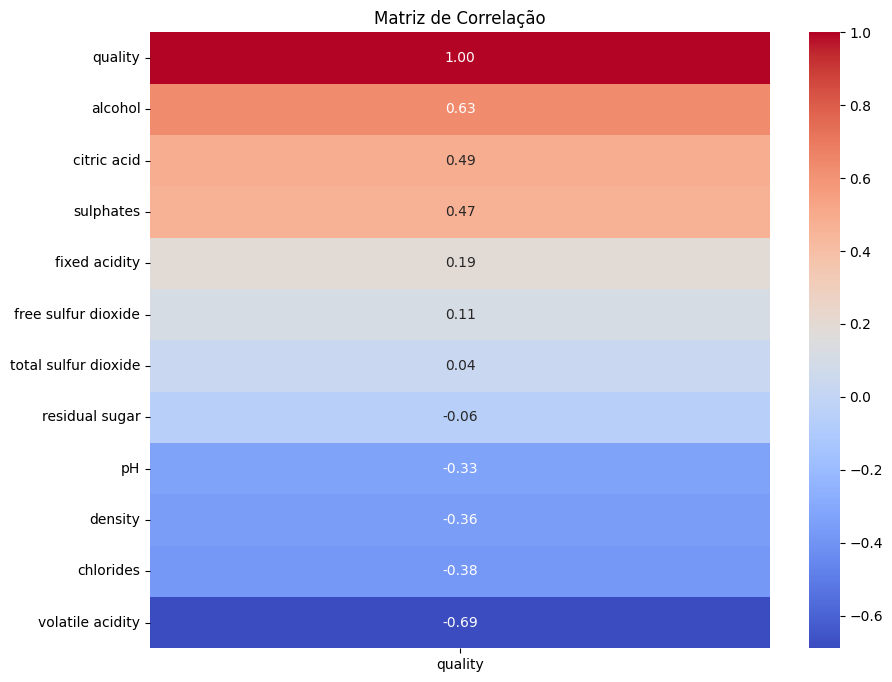

In [86]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
correlation_matrix.sort_values(by='quality', ascending=False, inplace=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['quality']], annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

O mapa acima evidencia as correlaçlões entre as variáveis exploratorias e a alvo. É possível confirmar que as características que mais influemciam são álcolol e acidez volátil seguidas de ácido cítrico e sulfetos. Em seguida, temos os cloroides, pH, densidade, acidez fixa e dióxido de sulfeto livre.

Para avaliar as demais correlções, o mapa de calor publicado destacou apenas as correlações superiores a 0.5.
Como esperado, destacam-se as relações entre medidas de acidez (acidez cítrica, fixa e volátil), medidas de sulfetos (livre e total) e entre medidas de densidade, álcool e acidez.

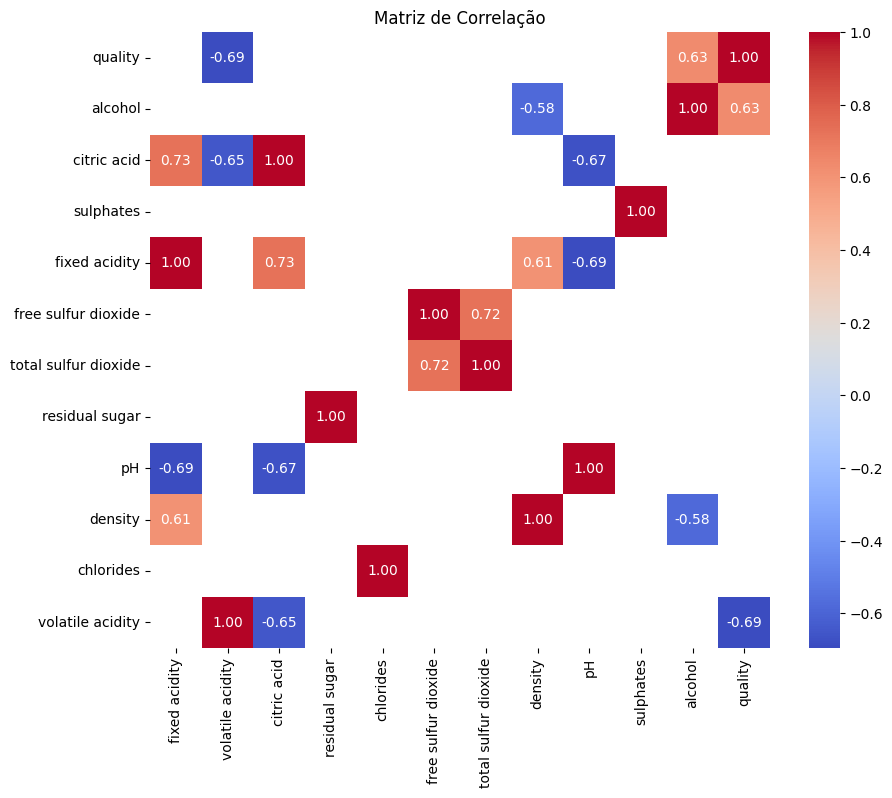

In [87]:
plt.figure(figsize=(10, 8))
correlation_matrix_strong = correlation_matrix[correlation_matrix.abs() > 0.5]
sns.heatmap(correlation_matrix_strong, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

#### Dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)

In [138]:
df_corr = df[['quality', 'alcohol', 'volatile acidity', 'citric acid', 'sulphates' ]].copy()

# Preparação Final dos Dados

Agora as bases serão separadas em base em X(Features) e Y(Target) e entre treino e teste.

In [107]:
from sklearn.model_selection import train_test_split
# Separar os dados em features (X) e o alvo (y)
X = df.select_dtypes(include=['int64', 'float64']).drop(columns=['quality'])
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Modelagem

Preparadas as bases, inicia-se a etapa de treino  do modelo Random FOrest e a aplicação do modelo teste.

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [110]:
# Treinando modelo
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [111]:
# Fazendo previsões no conjunto de teste
y_pred = rf_model.predict(X_test)

# Avaliação

Para avaliar o modelos, serão analisadas suas principais métricas de claissificação

In [112]:
# Avaliando o modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.86
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.96      1.00      0.98       162
           4       0.86      0.97      0.91       165
           5       0.77      0.77      0.77       168
           6       0.78      0.60      0.67       198
           7       0.82      0.87      0.85       158
           8       0.95      0.99      0.97       165

    accuracy                           0.86      1016
   macro avg       0.86      0.87      0.86      1016
weighted avg       0.85      0.86      0.85      1016

Matriz de Confusão:
 [[162   0   0   0   0   0]
 [  1 160   3   0   1   0]
 [  2  13 130  19   4   0]
 [  3  11  36 118  24   6]
 [  0   2   0  15 138   3]
 [  0   0   0   0   1 164]]


#### Precisão

A precisão mede o percentual das previsões positivas corretas. Ou seja, indica o percentual de previsão corretas em relação a todas as previsões positivas feitas para cada classe.
Os resultados mostram a seguinte ordem decrescente de precisão: 3, 8, 4, 7, 6 e 5.

#### Recall

O recall mede o percentual das previsões positivas corretas em relação a todos os casos positivos de cada classe. 
Os resultados mostram a seguinte ordem decrescente de recall: 3, 8, 4, 7, 5 e 6.

#### F1

F1 é a média harmônica da precisão e do recall.
Os resultados mostram a seguinte ordem decrescente de: 3, 8, 4, 7, 5 e 6.

#### Matriz Confusão

A matriz confusão deve ser interpretada da seguinte forma: as colunas e linhas devem ser etiquetadas com as classes avaliadas, conforme a configuração a baixo.

____3____4____5____6____7____8

__3

__4

__5

__6

__7

__8

A diagonal da matrix indica os valores verdadeiros, os valores fora da diagonal são os falsos. As colunas trazem as previsões Positivas para cada coluna, e as linhas, as previsões Negativas para cada linha.

Por exemplo, para a classe 3, a matriz indicará:

___3___4___5___6___7___8

3 VP__FN__FN__FN__FN__FN

4 FP__VN

5 FP______VN

6 FP__________VN

7 FP______________VN

8 FP__________________VN

Vale lembrar que:

- Falso Positivo significa "Previu que era, mas era.".
- Falso Negativos significa "Previu que não era, mas era.".
- Verdadeiro Negativo significa "Previu que não era, e não era.".
- Verdadeiro Positivo significa "Previu que era, e era."

A partir do exposto, a matriz etiquetada segue o seguinte padrão:

____3    4   5   6   7   8

3 [162   0   0   0   0   0]

4 [  1 160   3   0   1   0]

5 [  2  13 130  19   4   0]

6 [  3  11  36 118  24   6]

7 [  0   2   0  15 138   3]

8 [  0   0   0   0   1 164]

Para a classe 3, foram 6 Falsos Positivos e 0 Falsos Negativos
Para o classe 4, foram 24 Falsos Positivos e 4 Falsos Negativos.
Para o classe 5, foram 39 Falsos Positivos e 28 Falsos Negativos.
Para o classe 6, foram 34 Falsos Positivos e 74 Falsos Negativos.
Para o classe 7, foram 30 Falsos Positivos e 20 Falsos Negativos.
Para o classe 8, foram 9 Falsos Positivos e 1 Falso Negativo.


#### Interpretação
Para todos os parâmetros analisados, as classes que pior performaram foram a 5 e a 6. Curiosamente, essas são também as classes que, antes do balanceamento, tinha a maior concentração dos dados.
O balanceamento dos dados replica os dados de cada classe, aumentando o banco de dados gerais, até que todas as classes tenham a mesma quantidade de dados. Neste caso, isso pode ter afetado o modelo a medida que ele foi muito bem treinando para o mesmo trecho de dados para as demais classes. Considerando que o banco de treino foi separado após o balanceamento, é possível que essa repetição tenha gerado bancos de teste e treino muito similares. Esse resultado sugere que o balanceamento da base seja feita após a separação, e apenas na base de teste. 
Outros efeitos podem ter contribuído, como a transforamção dos dados. Contudo, a evidência aponta para um overfitting devido ao balancemaento precoce dos dados.

# Melhorando os Hyperparametros

Definição d Grid de parametros

In [130]:
param_grid = {
    'n_estimators': [100, 200, 300], # Número de árvores na floresta
    'max_depth': [None, 20, 30, 40], # Profundidade máxima das árvores
    'min_samples_split': [5, 10, 20], # Número mínimo de amostras necessárias para dividir um nó
    'min_samples_leaf': [1, 4, 8], # Número mínimo de amostras necessárias para estar em um nó folha
    'max_features': ['sqrt', 'log2', None] # Número de recursos a serem considerados para encontrar a melhor divisão
}


Treinamento do modelo com random search.


In [131]:
# Configurando o Randomized Search
random_search = RandomizedSearchCV(estimator=rf_model, # especifica o modelo base que será ajustado
                                   param_distributions=param_grid, # o dicionário de hiperparâmetros a serem amostrados
                                   n_iter=100, # o número de combinações diferentes de hiperparâmetros a serem testadas
                                   cv=5, # o número de dobras para a validação cruzada
                                   n_jobs=-1, verbose=2, random_state=42, scoring='accuracy')
# Executando o Randomized Search
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=20, n_estimators=100; total time=   0.6s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=20, n_estimators=100; total time=   0.6s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.7s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=20, n_estimators=100; total time=   0.8s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.8s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=20, n_estimato

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [None, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 4, 8],
                                        'min_samples_split': [5, 10, 20],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='accuracy', verbose=2)

In [132]:
# Obtendo os melhores hiperparâmetros através do método randomico
best_params = random_search.best_params_
for i in best_params:
    print(f"{i}: {best_params[i]}")

n_estimators: 100
min_samples_split: 5
min_samples_leaf: 1
max_features: log2
max_depth: 20


**n_estimators**: Este parâmetro define o número de árvores na floresta.

**min_samples_split**: Este parâmetro define o número mínimo de amostras necessárias para dividir um nó.

**min_samples_leaf**: Este parâmetro especifica o número mínimo de amostras que um nó folha deve ter.

**max_features**: Este parâmetro define o número de características a serem consideradas ao procurar a melhor divisão. Com log2, o modelo considera o logaritmo de base 2 do número total de características.

**max_depth**: Este parâmetro especifica a profundidade máxima das árvores na floresta.

In [133]:
# Treinando o modelo com os melhores hiperparâmetros encontrados acima
best_rf_model = random_search.best_estimator_
best_rf_model.fit(X_train, y_train)
y_pred = best_rf_model.predict(X_test)

#### Avaliação do modelo



In [134]:
accuracy2 = accuracy_score(y_test, y_pred)
report2 = classification_report(y_test, y_pred)
conf_matrix2 = confusion_matrix(y_test, y_pred)

print(f"Acurácia: {accuracy2:.2f}")
print("Relatório de Classificação:\n", report2)
print("Matriz de Confusão:\n", conf_matrix2)

Acurácia: 0.86
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.98      1.00      0.99       162
           4       0.89      0.96      0.92       165
           5       0.74      0.78      0.76       168
           6       0.77      0.61      0.68       198
           7       0.81      0.87      0.84       158
           8       0.96      0.99      0.98       165

    accuracy                           0.86      1016
   macro avg       0.86      0.87      0.86      1016
weighted avg       0.86      0.86      0.86      1016

Matriz de Confusão:
 [[162   0   0   0   0   0]
 [  1 159   2   2   1   0]
 [  3   9 131  20   5   0]
 [  0   9  41 120  25   3]
 [  0   2   2  13 138   3]
 [  0   0   0   0   1 164]]


In [129]:
print(f"Report 1:\n{report}\nReport 2:\n{report2}")

Report 1:
              precision    recall  f1-score   support

           3       0.96      1.00      0.98       162
           4       0.86      0.97      0.91       165
           5       0.77      0.77      0.77       168
           6       0.78      0.60      0.67       198
           7       0.82      0.87      0.85       158
           8       0.95      0.99      0.97       165

    accuracy                           0.86      1016
   macro avg       0.86      0.87      0.86      1016
weighted avg       0.85      0.86      0.85      1016

Report 2:
              precision    recall  f1-score   support

           3       0.97      1.00      0.98       162
           4       0.89      0.96      0.93       165
           5       0.77      0.80      0.79       168
           6       0.78      0.61      0.69       198
           7       0.83      0.90      0.86       158
           8       0.96      0.99      0.98       165

    accuracy                           0.87      1016
   

In [135]:
print(f"Comparação entre modelos. Diferença entre o modelo 1 e 2:\nAcurácio: {accuracy-accuracy2}\nMatriz Confusão:\n{conf_matrix-conf_matrix2}")

Comparação entre modelos. Diferença entre o modelo 1 e 2:
Acurácio: -0.0019685039370078705
Matriz Confusão:
[[ 0  0  0  0  0  0]
 [ 0  1  1 -2  0  0]
 [-1  4 -1 -1 -1  0]
 [ 3  2 -5 -2 -1  3]
 [ 0  0 -2  2  0  0]
 [ 0  0  0  0  0  0]]


Ao comparar os modelos nas linhas acima, as melhorias não foram relevantes.
Foram testados diversos parâmetros da grid, mas os resultados foram todos similares.

# Melhorias futuras

Umas das alternativas para melhorar o modelo é melhorar o tratamento de dados. Conforme previamente discutido, o balancemaneto dos dados. Essa alteração pode afetar outras etapas do tratamento de dados, como o tratamento de dados e a redução do banco em função da matriz de correlação.
Adicionalmento, para melhorar os parâmetros de grid, se faz necessário o aprofundamento no estudo dos impactos de cada parâmetro no modelo.

